Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Upload and Read Image

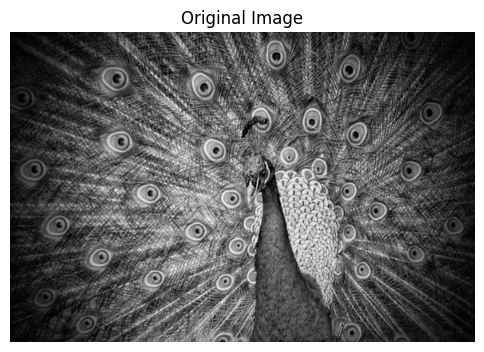

In [ ]:
# 1. Read image in grayscale
img = cv2.imread('/content/peacock_animal_iridescent_217507.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Image not found!")
    exit()
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

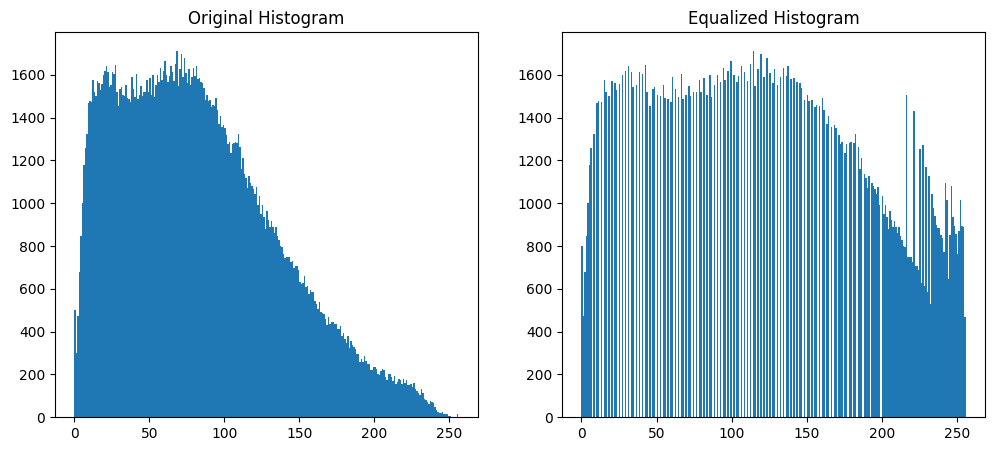

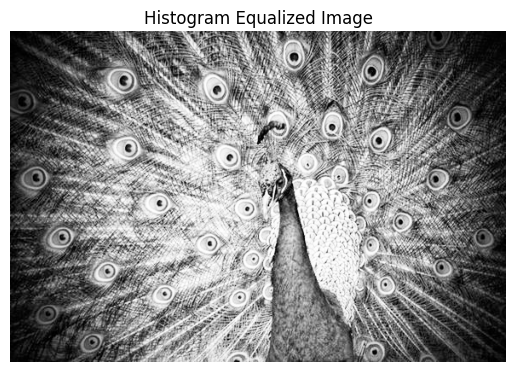

In [ ]:
# Histogram before equalization
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=(0,256))
plt.title('Original Histogram')

# Equalization
equalized = cv2.equalizeHist(img)

# Histogram after equalization
plt.subplot(1,2,2)
plt.hist(equalized.ravel(), bins=256, range=(0,256))
plt.title('Equalized Histogram')
plt.show()

# Display equalized image
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')
plt.show()


In [ ]:
# Mean Filter
mean_filtered = cv2.blur(img, (5,5))

# Median Filter
median_filtered = cv2.medianBlur(img, 5)

# Gaussian Filter
gaussian_filtered = cv2.GaussianBlur(img, (5,5), 0)

#laplacian filter
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)

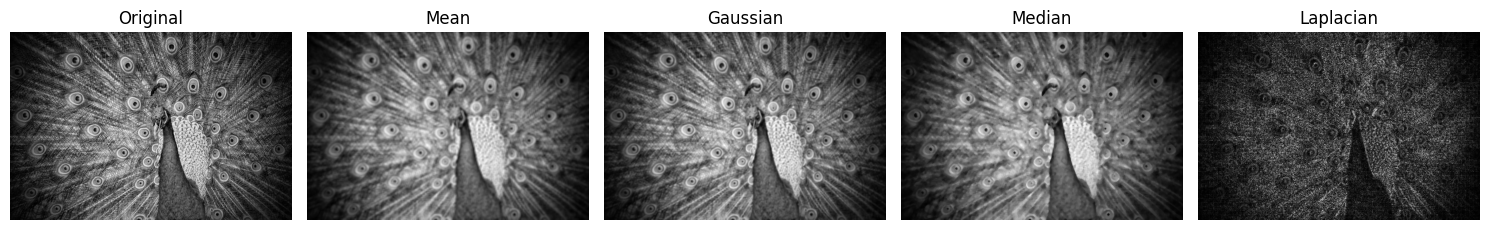

In [ ]:
# Display Spatial Filters
titles = ['Original', 'Mean', 'Gaussian', 'Median', 'Laplacian']
images = [img, mean_filtered, gaussian_filtered, median_filtered, laplacian_abs]

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 6. Frequency Domain Filters

def ideal_low_pass(img, cutoff):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.zeros_like(img)
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i - crow) ** 2 + (j - ccol) ** 2) < cutoff:
                mask[i, j] = 1

    filtered = dft_shift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.abs(img_back)


In [ ]:
def ideal_high_pass(img, cutoff):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.ones_like(img)
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i - crow) ** 2 + (j - ccol) ** 2) < cutoff:
                mask[i, j] = 0

    filtered = dft_shift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
    return np.abs(img_back)

low_pass = ideal_low_pass(img, 30)
high_pass = ideal_high_pass(img, 30)


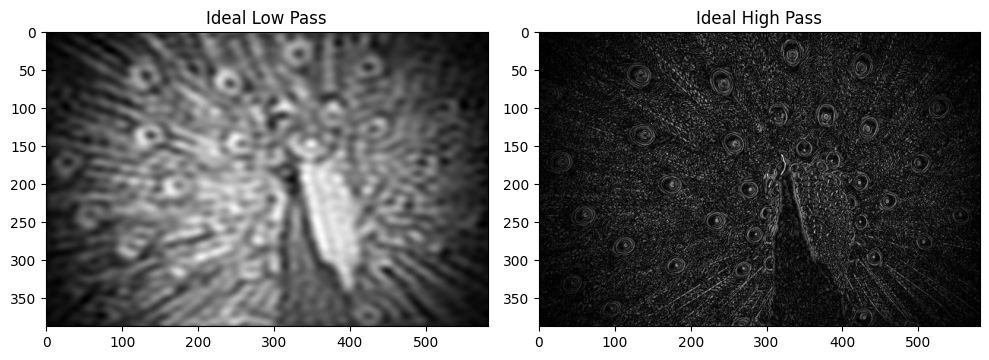

In [ ]:
# Display Frequency Filters
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(low_pass, cmap='gray')
plt.title("Ideal Low Pass")

plt.subplot(1, 2, 2)
plt.imshow(high_pass, cmap='gray')
plt.title("Ideal High Pass")
plt.tight_layout()
plt.show()

In [ ]:
print("""
=== OBSERVATIONS ===
1. Histogram Equalization spreads pixel intensity values and enhances contrast.
2. Mean Filter smoothens the image but blurs edges.
3. Median Filter removes salt-and-pepper noise effectively while keeping edges sharp.
4. Gaussian Filter smoothens the image and reduces random noise.
5. Low-Pass Filter (in frequency domain) removes high-frequency components,
   resulting in a softer, blurrier image.
""")



=== OBSERVATIONS ===
1. Histogram Equalization spreads pixel intensity values and enhances contrast.
2. Mean Filter smoothens the image but blurs edges.
3. Median Filter removes salt-and-pepper noise effectively while keeping edges sharp.
4. Gaussian Filter smoothens the image and reduces random noise.
5. Low-Pass Filter (in frequency domain) removes high-frequency components, 
   resulting in a softer, blurrier image.

